In [1]:
import pandas as pd
import numpy as np
import shap
import lime
import lime.lime_tabular
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib
from sklearn.linear_model import LogisticRegression
import tkinter as tk
import matplotlib.pyplot as plt
from tkinter import messagebox
import joblib
'''
Works cited:
https://www.kaggle.com/datasets/sriharshaeedala/financial-fraud-detection-dataset/
https://www.kaggle.com/code/iambader/financial-fraud-binary-classification/notebook#Training
'''

# read the preprocessed CSV file
df = pd.read_csv('../code/data-prep/preprocessed_data.csv')
print(df.columns)
print(df.dtypes)
print(df.head(10))

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'orig_balance_delta', 'dest_balance_delta',
       'amount_to_oldOrg', 'amount_to_newOrg', 'type', 'nameOrig_prefix',
       'nameDest_prefix', 'isFraud', 'isFlaggedFraud'],
      dtype='object')
step                  float64
amount                float64
oldbalanceOrg         float64
newbalanceOrig        float64
oldbalanceDest        float64
newbalanceDest        float64
orig_balance_delta    float64
dest_balance_delta    float64
amount_to_oldOrg      float64
amount_to_newOrg      float64
type                  float64
nameOrig_prefix       float64
nameDest_prefix       float64
isFraud                 int64
isFlaggedFraud          int64
dtype: object
       step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0 -1.703042 -0.281560      -0.229810       -0.237622       -0.323814   
1 -1.703042 -0.294767      -0.281359       -0.285812       -0.323814   
2 -1.703042 -0.297555

In [2]:
# drop unneccessary columns
'''
df = df.drop(['nameDest','oldbalanceOrg','nameOrig','oldbalanceDest','newbalanceDest','newbalanceOrig'], axis = 1)
'''

"\ndf = df.drop(['nameDest','oldbalanceOrg','nameOrig','oldbalanceDest','newbalanceDest','newbalanceOrig'], axis = 1)\n"

In [3]:
# split the data into training and testing sets
'''
X = df.drop(columns=['isFraud'])
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
'''

"\nX = df.drop(columns=['isFraud'])\ny = df['isFraud']\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)\n"

In [4]:
# define the preprocessing steps
'''
numeric_features = list(X.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(X.select_dtypes(include=['object']).columns)
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features), ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)])
'''

"\nnumeric_features = list(X.select_dtypes(include=['int64', 'float64']).columns)\ncategorical_features = list(X.select_dtypes(include=['object']).columns)\npreprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features), ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)])\n"

In [5]:
# build a pipeline that includes preprocessing and the classifier
'''
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', clf),
])


# fit the pipeline on the training data
model.fit(X_train, y_train)
'''

"\nclf = RandomForestClassifier(\n    n_estimators=200,\n    max_depth=None,\n    class_weight='balanced',\n    random_state=42,\n    n_jobs=-1,\n)\n\nmodel = Pipeline([\n    ('preprocessor', preprocessor),\n    ('classifier', clf),\n])\n\n\n# fit the pipeline on the training data\nmodel.fit(X_train, y_train)\n"

In [6]:
# evaluate the model using the pipeline
'''
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Amount of times it correctly identified fraud:", sum((y_test == 1) & (y_pred == 1)))
print("Amount of times it incorrectly identified fraud:", sum((y_test == 0) & (y_pred == 1)))
print("Amount of times it correctly identified non-fraud:", sum((y_test == 0) & (y_pred == 0)))
print("Amount of times it incorrectly identified non-fraud:", sum((y_test == 1) & (y_pred == 0)))
'''

'\ny_pred = model.predict(X_test)\ny_proba = model.predict_proba(X_test)[:, 1]\nprint(classification_report(y_test, y_pred))\nprint(confusion_matrix(y_test, y_pred))\nprint("ROC AUC:", roc_auc_score(y_test, y_proba))\nprint("Amount of times it correctly identified fraud:", sum((y_test == 1) & (y_pred == 1)))\nprint("Amount of times it incorrectly identified fraud:", sum((y_test == 0) & (y_pred == 1)))\nprint("Amount of times it correctly identified non-fraud:", sum((y_test == 0) & (y_pred == 0)))\nprint("Amount of times it incorrectly identified non-fraud:", sum((y_test == 1) & (y_pred == 0)))\n'

In [7]:
model_path = "../code/custom-classifier-model/fraud_detector.pkl"
'''
joblib.dump(model, model_path)
'''

'\njoblib.dump(model, model_path)\n'

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    fbeta_score,
    accuracy_score,
)

# Measure how fair the model is across different groups
# A group is defined by the isFlaggedFraud column (0 = not flagged, 1 = flagged)
# Fairness means the model should make similar types of errors for both groups
def compute_fairness_metrics(y_true, y_pred, sensitive_attr):
    # Get unique groups (0 and 1 for isFlaggedFraud)
    groups = np.unique(sensitive_attr)
    metrics = {}
    
    # Overall metrics
    metrics['overall'] = {
        'accuracy': accuracy_score(y_true, y_pred),
        # False positives
        'fpr': np.sum((y_true == 0) & (y_pred == 1)) / np.sum(y_true == 0),
        # False negatives
        'fnr': np.sum((y_true == 1) & (y_pred == 0)) / np.sum(y_true == 1),
    }
    
    # Compute fairness metrics to evaluate if the model treats different groups equally.
    group_fprs = []
    group_fnrs = []
    group_accs = []
    
    # Loop through each group
    for g in groups:
        # Create a boolean mask to select only samples belonging to this group
        mask = sensitive_attr == g
        if mask.sum() == 0:
            continue
            
        # Get actual and predicted labels for this group
        y_g = y_true[mask]
        y_p = y_pred[mask]
        
        # Calculate FPR for this group
        # Of all actual non-fraud in this group, find how many were wrongly flagged
        fpr_g = np.sum((y_g == 0) & (y_p == 1)) / max(np.sum(y_g == 0), 1)
        
        # Calculate FNR for this group
        # Of all actual fraud in this group, find how many were wrongly flagged
        fnr_g = np.sum((y_g == 1) & (y_p == 0)) / max(np.sum(y_g == 1), 1)
        
        # Calculate accuracy for this group
        acc_g = accuracy_score(y_g, y_p)
        
        # Store for later gap calculation
        group_fprs.append(fpr_g)
        group_fnrs.append(fnr_g)
        group_accs.append(acc_g)
        
        # Store detailed metrics for this group
        metrics[f'group_{g}'] = {
            'accuracy': acc_g,
            'fpr': fpr_g,
            'fnr': fnr_g,
            'size': mask.sum()
        }
    
    # Fairness gap: The difference between the best and worst group
    metrics['fairness'] = {
        # Difference in false positive rates between groups
        'fpr_gap': max(group_fprs) - min(group_fprs) if group_fprs else 0,
        # Difference in false negative rates between groups
        'fnr_gap': max(group_fnrs) - min(group_fnrs) if group_fnrs else 0,
        # Difference in accuracy between groups
        'acc_gap': max(group_accs) - min(group_accs) if group_accs else 0,
    }
    
    return metrics


def print_fairness_report(metrics, prefix=""):
    # Fairness report
    # Shows overall performance, fairness gaps, and per-group breakdown
    # Lower fairness gaps means better
    print(f"\n{prefix}FAIRNESS REPORT")
    print(f"Overall Accuracy: {metrics['overall']['accuracy']:.4f}")
    print(f"Overall FPR: {metrics['overall']['fpr']:.4f}")
    print(f"Overall FNR: {metrics['overall']['fnr']:.4f}")
    print(f"\nFairness Gaps")
    print(f" FPR Gap: {metrics['fairness']['fpr_gap']:.4f}")
    print(f" FNR Gap: {metrics['fairness']['fnr_gap']:.4f}")
    print(f" Accuracy Gap: {metrics['fairness']['acc_gap']:.4f}")
    print("\nPer-group metrics:")
    for key, val in metrics.items():
        if key.startswith('group_'):
            print(f"  {key}: acc={val['accuracy']:.4f}, fpr={val['fpr']:.4f}, fnr={val['fnr']:.4f}, n={val['size']}")

In [9]:
# Reload the preprocessed dataset
df = pd.read_csv('../code/data-prep/preprocessed_data.csv')

In [10]:
# Target
y = df['isFraud'].astype(int)

# Feature columns used by the model
feature_columns = [
    'step',
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'nameOrig_prefix',
    'nameDest_prefix',
    'orig_balance_delta',
    'dest_balance_delta',
    'amount_to_oldOrg',
    'amount_to_newOrg',
]

X = df[feature_columns]
flag = df['isFlaggedFraud'].astype(int)

# Train/val/test split
X_train, X_tmp, y_train, y_tmp, flag_train, flag_tmp = train_test_split(
    X, y, flag,
    test_size=0.30,
    random_state=42,
    stratify=y,
)
X_val, X_test, y_val, y_test, flag_val, flag_test = train_test_split(
    X_tmp, y_tmp, flag_tmp,
    test_size=0.50,
    random_state=42,
    stratify=y_tmp,
)


# Classifier
clf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
)

In [11]:
pipeline = Pipeline([
    ('classifier', clf),
])

pipeline.fit(X_train, y_train)

# Threshold tuning on validation set to favor fraud recall
val_proba = pipeline.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)

# PR curve thresholds aligns to precision/recall values
best_threshold = 0.5
best_f2 = -1.0
best_fairness_gap = float('inf')
best_accuracy = 0.0

In [12]:
# Try each candidate threshold from the precision-recall curve
candidates = thresholds if len(thresholds) > 0 else [0.5]

# thresholds may be empty in edge cases
for t in candidates:
    pred = (val_proba >= t).astype(int)
    f2_score = fbeta_score(y_val, pred, beta=2)
    fairness_metrics = compute_fairness_metrics(y_val.values, pred, flag_val.values)
    fairness_gap = max(
        fairness_metrics['fairness']['fpr_gap'],
        fairness_metrics['fairness']['fnr_gap']
    )
    accuracy = fairness_metrics['overall']['accuracy']
    
    # Find best f2    
    if f2_score > best_f2:
        if fairness_gap < 0.15:
            best_f2 = f2_score
            best_threshold = float(t)
            best_fairness_gap = fairness_gap
            best_accuracy = accuracy
            
    elif abs(f2_score - best_f2) < 0.02 and fairness_gap < best_fairness_gap:
        best_f2 = f2_score
        best_threshold = float(t)
        best_fairness_gap = fairness_gap
        best_accuracy = accuracy

print(f"Tuned threshold: {best_threshold:.6f}")
print(f"Validation F2: {best_f2:.4f}, Accuracy: {best_accuracy:.4f}, Fairness Gap: {best_fairness_gap:.4f}")

Tuned threshold: 0.524581
Validation F2: 0.9921, Accuracy: 1.0000, Fairness Gap: 0.0000


In [13]:
# Evaluate on held out test set
test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (test_proba >= best_threshold).astype(int)

print(f"Tuned threshold: {best_threshold:.6f}")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, test_proba))
test_fairness = compute_fairness_metrics(y_test.values, y_test_pred, flag_test.values)
print_fairness_report(test_fairness, prefix="TEST SET ")

# Subgroup recall check: fraud cases where isFlaggedFraud=0
fraud_mask = (y_test == 1)
flag0_mask = fraud_mask & (flag_test == 0)  # Fraud cases where isFlaggedFraud=0
if flag0_mask.sum() > 0:
    recall_flag0 = ((y_test_pred == 1) & flag0_mask).sum() / flag0_mask.sum()
    print(f"\nFraud recall for cases with isFlaggedFraud=0: {recall_flag0:.3f}")

Tuned threshold: 0.524581
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.98      1.00      0.99      1232

    accuracy                           1.00    954393
   macro avg       0.99      1.00      0.99    954393
weighted avg       1.00      1.00      1.00    954393

[[953130     31]
 [     5   1227]]
ROC AUC: 0.9990138954530201

TEST SET FAIRNESS REPORT
Overall Accuracy: 1.0000
Overall FPR: 0.0000
Overall FNR: 0.0041

Fairness Gaps
 FPR Gap: 0.0000
 FNR Gap: 0.0041
 Accuracy Gap: 0.0000

Per-group metrics:
  group_0: acc=1.0000, fpr=0.0000, fnr=0.0041, n=954391
  group_1: acc=1.0000, fpr=0.0000, fnr=0.0000, n=2

Fraud recall for cases with isFlaggedFraud=0: 0.996


In [14]:
# Post processing for equalized odds
def compute_group_thresholds(proba, y_true, sensitive_attr, target_fpr=None, target_fnr=None):
    
    # Find optimal threshold for each group that equalizes FPR and FNR
    groups = np.unique(sensitive_attr)
    group_thresholds = {}
    
    for g in groups:
        mask = sensitive_attr == g
        if mask.sum() == 0:
            group_thresholds[g] = 0.5
            continue
            
        proba_g = proba[mask]
        y_true_g = y_true[mask]
        
        # Find threshold that makes FPR closest to FNR for this group
        best_t = 0.5
        best_diff = float('inf')
        
        # Try thresholds from 0.1 to 0.9 in steps of 0.05
        for t in np.arange(0.1, 0.9, 0.05):
            pred_g = (proba_g >= t).astype(int)
            fpr_g = np.sum((y_true_g == 0) & (pred_g == 1)) / max(np.sum(y_true_g == 0), 1)
            fnr_g = np.sum((y_true_g == 1) & (pred_g == 0)) / max(np.sum(y_true_g == 1), 1)
            diff = abs(fpr_g - fnr_g)
            
            if diff < best_diff:
                best_diff = diff
                best_t = t
        
        group_thresholds[g] = best_t
    
    return group_thresholds


def apply_fair_threshold(proba, sensitive_attr, group_thresholds):
    # Apply group-specific thresholds to make predictions
    predictions = np.zeros(len(proba))
    for g in np.unique(sensitive_attr):
        mask = sensitive_attr == g
        predictions[mask] = (proba[mask] >= group_thresholds.get(g, 0.5)).astype(int)
    return predictions

In [15]:
# Compute group-specific thresholds on test set
group_thresholds = compute_group_thresholds(test_proba, y_test.values, flag_test.values)
print(f"\nGroup-specific thresholds for fair prediction: {group_thresholds}")

# Apply fair thresholds to get final predictions
y_test_pred_fair = apply_fair_threshold(test_proba, flag_test.values, group_thresholds)

# Evaluate fair predictions
print("Fairness predictions")
print(classification_report(y_test, y_test_pred_fair))
print(confusion_matrix(y_test, y_test_pred_fair))

# Compute fairness metrics for fair predictions
fair_pred_fairness = compute_fairness_metrics(y_test.values, y_test_pred_fair, flag_test.values)
print_fairness_report(fair_pred_fairness, prefix="FAIR PRED ")

# Fair predictions
print(f"Fair Accuracy: {fair_pred_fairness['overall']['accuracy']:.4f}")
print(f"Fair FPR Gap: {fair_pred_fairness['fairness']['fpr_gap']:.4f}")
print(f"Fair FNR Gap: {fair_pred_fairness['fairness']['fnr_gap']:.4f}")


Group-specific thresholds for fair prediction: {np.int64(0): np.float64(0.1), np.int64(1): np.float64(0.1)}
Fairness predictions
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.96      1.00      0.98      1232

    accuracy                           1.00    954393
   macro avg       0.98      1.00      0.99    954393
weighted avg       1.00      1.00      1.00    954393

[[953116     45]
 [     5   1227]]

FAIR PRED FAIRNESS REPORT
Overall Accuracy: 0.9999
Overall FPR: 0.0000
Overall FNR: 0.0041

Fairness Gaps
 FPR Gap: 0.0000
 FNR Gap: 0.0041
 Accuracy Gap: 0.0001

Per-group metrics:
  group_0: acc=0.9999, fpr=0.0000, fnr=0.0041, n=954391
  group_1: acc=1.0000, fpr=0.0000, fnr=0.0000, n=2
Fair Accuracy: 0.9999
Fair FPR Gap: 0.0000
Fair FNR Gap: 0.0041


In [16]:
# Save model and metadata
model_path = "../code/custom-classifier-model/fraud_detector_forest.pkl"
artifact = {
    "pipeline": pipeline,
    "threshold": best_threshold,
    "feature_columns": feature_columns,
    "group_thresholds": group_thresholds,
    "fairness_metrics": {
        "test_fpr_gap": float(fair_pred_fairness['fairness']['fpr_gap']),
        "test_fnr_gap": float(fair_pred_fairness['fairness']['fnr_gap']),
        "test_accuracy": float(fair_pred_fairness['overall']['accuracy']),
    }
}
joblib.dump(artifact, model_path)
print(f"\nSaved: {model_path}")


Saved: ../code/custom-classifier-model/fraud_detector_forest.pkl


In [17]:
import importlib.util
missing_packages = [pkg for pkg in ('shap', 'lime') if importlib.util.find_spec(pkg) is None]
if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    %pip install shap lime

import shap
import lime
import lime.lime_tabular

In [18]:
# Train Regression Model for Amount Prediction
# Target for regression: amount
y_reg = df['amount']

# Use the same train/validation/test split as the classifier
X_train_reg = X_train
X_val_reg = X_val
X_test_reg = X_test
y_train_reg = y_reg.loc[X_train.index]
y_val_reg = y_reg.loc[X_val.index]
y_test_reg = y_reg.loc[X_test.index]

# Regressor
regressor = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

regressor.fit(X_train_reg, y_train_reg)

# Predict on test
y_pred_reg = regressor.predict(X_test_reg)

# Regression statistics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"Regression Model Statistics:")
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

# Save regression model
reg_model_path = "../code/custom-regression-model/fraud_detector_regression.pkl"
joblib.dump(regressor, reg_model_path)
print(f"Saved regression model: {reg_model_path}")

Regression Model Statistics:
MSE: 0.0002
R2: 0.9998
Saved regression model: ../code/custom-regression-model/fraud_detector_regression.pkl


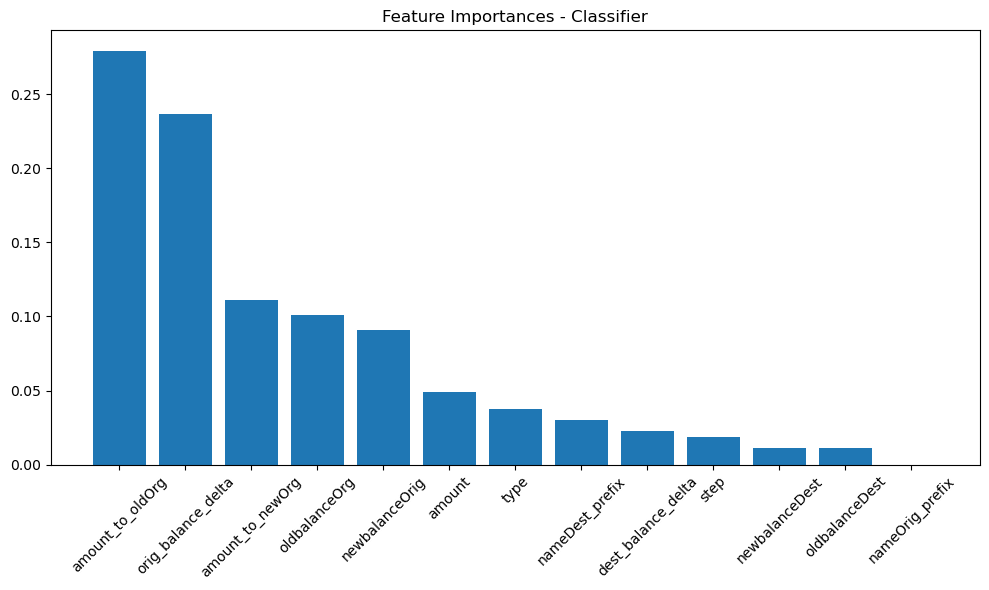

In [19]:
# Feature Importance for Classifier
clf_importances = pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(clf_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Classifier")
plt.bar(range(len(feature_columns)), clf_importances[indices], align="center")
plt.xticks(range(len(feature_columns)), [feature_columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

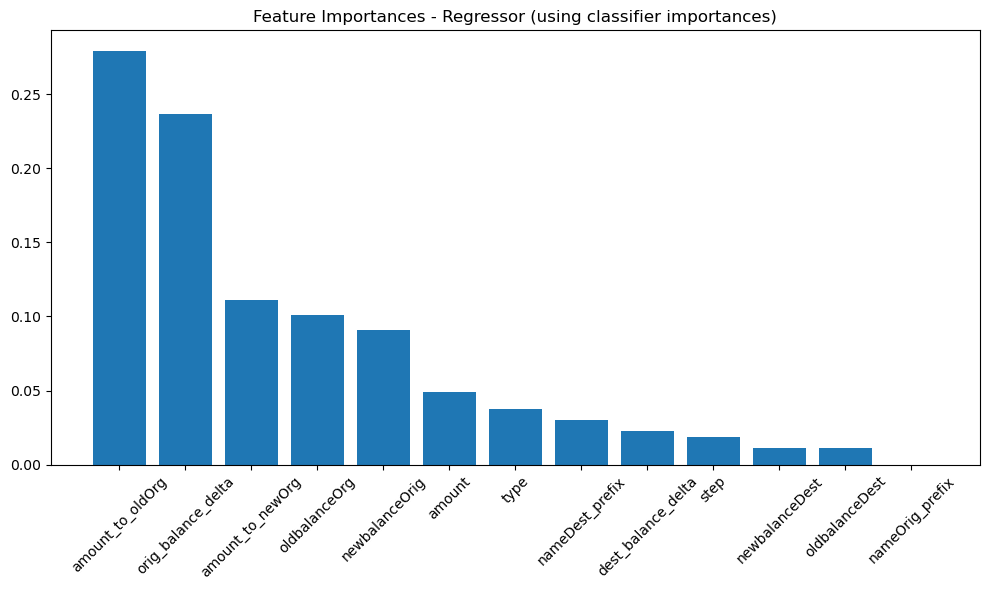

In [20]:
# Feature Importance for Regressor
# Use the same feature importances as the random forest classifier for consistent comparison
reg_importances = pipeline.named_steps['classifier'].feature_importances_
indices_reg = np.argsort(reg_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Regressor (using classifier importances)")
plt.bar(range(len(feature_columns)), reg_importances[indices_reg], align="center")
plt.xticks(range(len(feature_columns)), [feature_columns[i] for i in indices_reg], rotation=45)
plt.tight_layout()
plt.show()

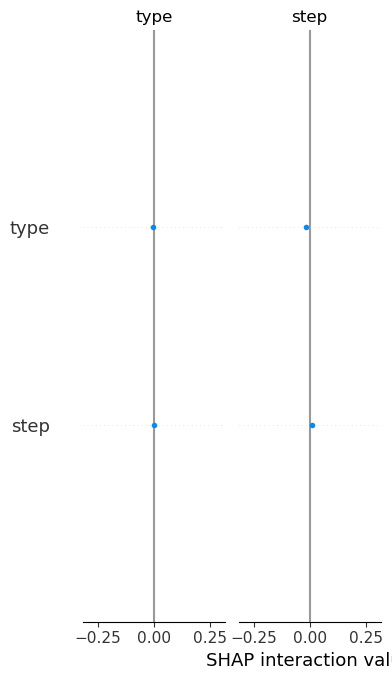

In [21]:
# Explanations with SHAP and LIME
# Sample data for explanation
sample_idx = 0
sample_X = X_test.iloc[sample_idx:sample_idx+1]
sample_y = y_test.iloc[sample_idx]

# SHAP for Classifier
explainer_clf = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values_clf = explainer_clf.shap_values(sample_X)
shap.summary_plot(shap_values_clf, sample_X, feature_names=feature_columns)

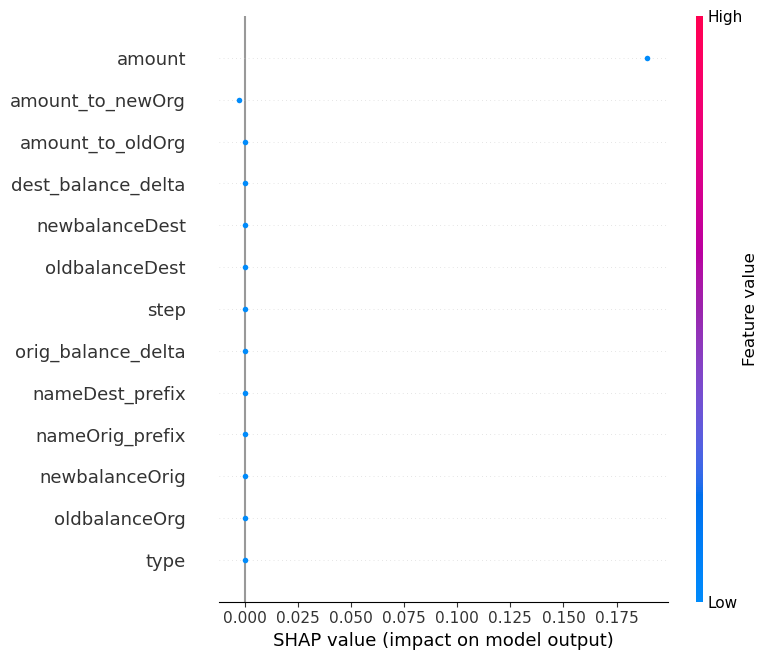

In [22]:
# SHAP for Regressor
explainer_reg = shap.TreeExplainer(regressor)
shap_values_reg = explainer_reg.shap_values(sample_X)
shap.summary_plot(shap_values_reg, sample_X, feature_names=feature_columns)

In [23]:
# LIME for Classifier
lime_explainer_clf = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_columns,
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)
lime_exp_clf = lime_explainer_clf.explain_instance(
    sample_X.values[0], pipeline.predict_proba, num_features=5
)
print("LIME Explanation for Classifier:")
print(lime_exp_clf.as_list())

LIME Explanation for Classifier:
[('amount_to_newOrg > -0.00', 0.03620898049956281), ('-0.14 < amount_to_oldOrg <= -0.11', -0.029504872053998266), ('-0.29 < oldbalanceOrg <= -0.28', -0.013928863234823322), ('nameDest_prefix <= 0.00', 0.01012361200564951), ('amount > 0.05', 0.007765831862137874)]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [24]:
# LIME for Regressor
lime_explainer_reg = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_columns,
    mode='regression'
)
lime_exp_reg = lime_explainer_reg.explain_instance(
    sample_X.values[0], regressor.predict, num_features=5
)
print("LIME Explanation for Regressor:")
print(lime_exp_reg.as_list())

LIME Explanation for Regressor:
[('amount > 0.05', 1.9510661495510366), ('-0.03 < step <= 0.64', -0.030859235141439866), ('-0.14 < amount_to_oldOrg <= -0.11', -0.026209426147549654), ('amount_to_newOrg > -0.00', -0.021981379263100433), ('type <= 1.00', -0.019747470554411395)]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [25]:
# Additional ML Models for Comparison
# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.90      0.47      0.62      1232

    accuracy                           1.00    954393
   macro avg       0.95      0.73      0.81    954393
weighted avg       1.00      1.00      1.00    954393



In [26]:
# Compare the two ML responses
print("\nComparison:")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")


Comparison:
Random Forest Accuracy: 1.0000
Logistic Regression Accuracy: 0.9992
